<a href="https://colab.research.google.com/github/PolPetr/python-course/blob/main/31/01_%22visuals_hw_ipynb%22_%D0%9F%D0%B5%D1%82%D1%80%D0%BE%D0%B2%D0%B0_%D0%9F_%D0%A1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое задание

## ЗАДАНИЕ 1: Базовые графики matplotlib

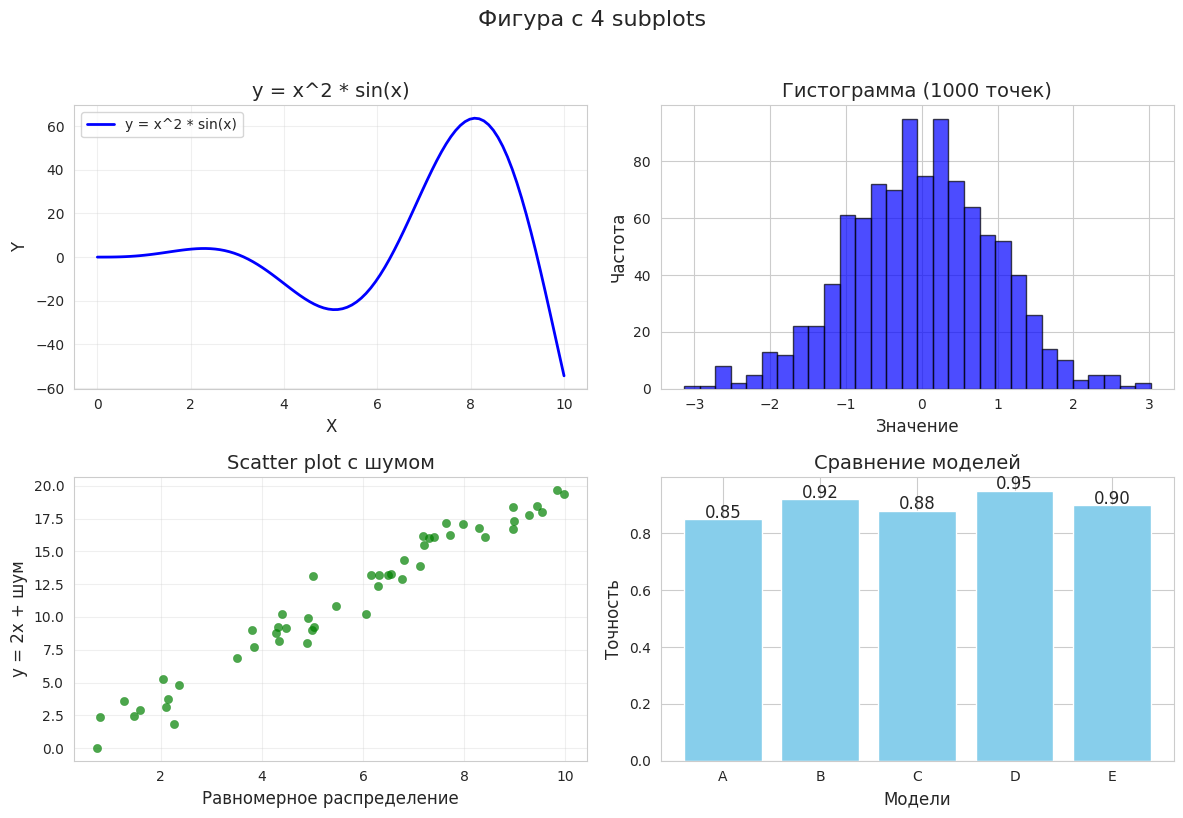

In [ ]:
# Создайте фигуру с 4 subplots (2x2):
# 1. Линейный график функции y = x^2 * sin(x) на интервале [0, 10]
#    Добавьте заголовок, подписи осей, сетку, легенду
# 2. Гистограмма 1000 случайных точек из нормального распределения
#    Настройте количество bins=30, добавьте заголовок
# 3. Scatter plot: 50 точек (x - равномерное распределение, y = 2x + шум)
#    Настройте размер точек, прозрачность, цвет
# 4. Bar chart: сравнение 5 разных моделей по точности
#    accuracy = [0.85, 0.92, 0.88, 0.95, 0.90]
#    Добавьте значения над столбцами

import numpy as np
import matplotlib.pyplot as plt

# Создаем фигуру с 4 subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2 строки, 2 столбца

# Название всей фигуры
fig.suptitle('Фигура с 4 subplots', fontsize=16, y=1.02)

# 1. Линейный график y = x^2 * sin(x)
ax = axes[0, 0]
x = np.linspace(0, 10, 100)
y = x**2 * np.sin(x)
ax.plot(x, y, 'b-', linewidth=2, label='y = x^2 * sin(x)')
ax.set_title('y = x^2 * sin(x)', fontsize=14)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.grid(True, alpha=0.3)  # alpha - прозрачность
ax.legend()

# 2. Гистограмма нормального распределения
ax = axes[0, 1]
data = np.random.normal(0, 1, 1000)
ax.hist(data, bins=30, alpha=0.7, color='blue', edgecolor='black')
ax.set_xlabel('Значение')
ax.set_ylabel('Частота')
ax.set_title('Гистограмма (1000 точек)')

# 3. Scatter plot: y = 2x + шум
ax = axes[1, 0]
x = np.random.uniform(0, 10, 50)
y = 2 * x + np.random.normal(0, 1, 50)
ax.scatter(x, y, alpha=0.7, color='green', edgecolors='green', linewidth=0.3)
ax.set_xlabel('Равномерное распределение')
ax.set_ylabel('y = 2x + шум')
ax.set_title('Scatter plot с шумом')
ax.grid(True, alpha=0.3)

# 4. Bar chart: точность моделей
ax = axes[1, 1]
models = ['A', 'B', 'C', 'D', 'E']
accuracy = [0.85, 0.92, 0.88, 0.95, 0.90]
bars = ax.bar(models, accuracy, color=['skyblue', 'skyblue', 'skyblue', 'skyblue', 'skyblue'])
ax.set_xlabel('Модели')
ax.set_ylabel('Точность')
ax.set_title('Сравнение моделей')

# Добавляем значения над столбцами
for bar, acc in zip(bars, accuracy):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{acc:.2f}', ha='center')

plt.tight_layout()
plt.show()

## ЗАДАНИЕ 2: Seaborn визуализации

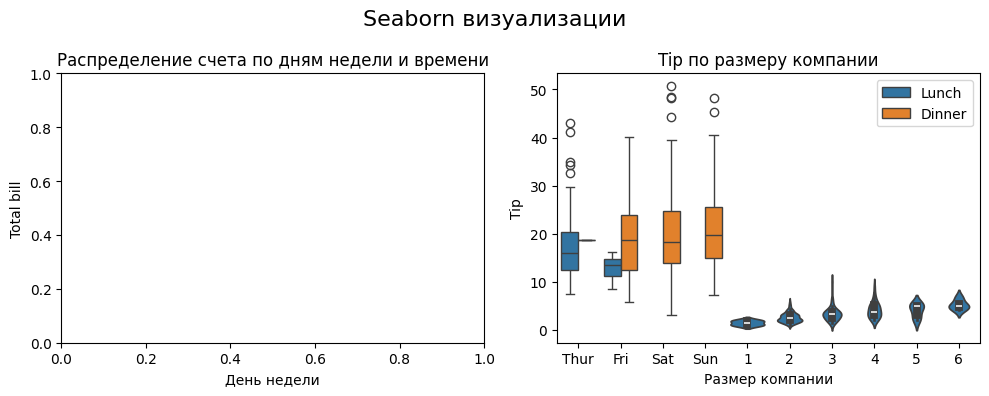

<Figure size 1200x1000 with 0 Axes>

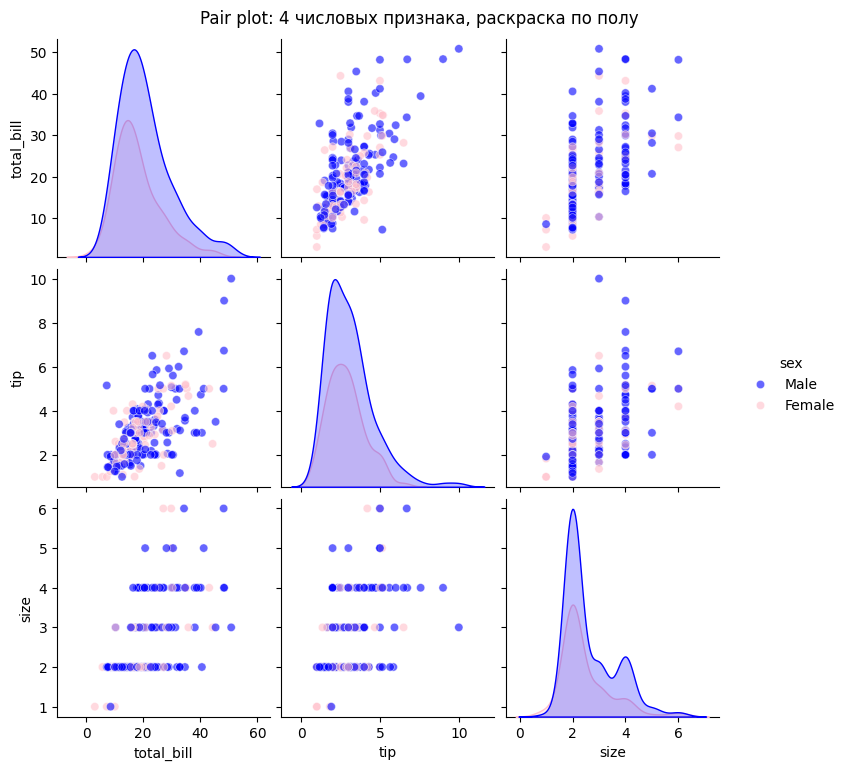

In [23]:
#Не понимаю, почему первый график не на месте: съезжает вправо

# Используйте датасет tips из seaborn:
import seaborn as sns
tips = sns.load_dataset('tips')

# Создайте 3 графика:
# 1. Box plot: total_bill по дням недели (day)
#    Разделите дополнительно по времени (time) с помощью hue
# 2. Violin plot: tip в зависимости от размера компании (size)
# 3. Pair plot: выберите 4 числовых признака, раскрасьте по полу (sex)

import seaborn as sns
import matplotlib.pyplot as plt

# Загружаем датасет
tips = sns.load_dataset('tips')

# Создаем фигуру для графиков
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Seaborn визуализации', fontsize=16)

# 1. Box plot: total_bill по дням с разделением по времени
# data=tips, x='day', y='total_bill', hue='time'
ax = axes[0]
sns.boxplot(data=tips, x='day', y='total_bill', hue='time')
ax.set_title('Распределение счета по дням недели и времени')
ax.set_xlabel('День недели')
ax.set_ylabel('Total bill')

# 2. Violin plot: tip по размеру компании
# x='size', y='tip'
ax = axes[1]
sns.violinplot(data=tips, x='size', y='tip')
ax.set_title('Tip по размеру компании')
ax.set_xlabel('Размер компании')
ax.set_ylabel('Tip')

plt.tight_layout()
plt.show()

# 3. Pair plot: 4 числовых признака, раскраска по полу
# tips[['total_bill', 'tip', 'size', 'sex']]
# Создаем отдельную фигуру для pair plot
plt.figure(figsize=(12, 10))
sns.pairplot(tips[['total_bill', 'tip', 'size', 'sex']],
             hue='sex',
             palette={'Male': 'blue', 'Female': 'pink'},
             plot_kws={'alpha': 0.6},
             diag_kind='kde')
plt.suptitle('Pair plot: 4 числовых признака, раскраска по полу', y=1.02)
plt.show()